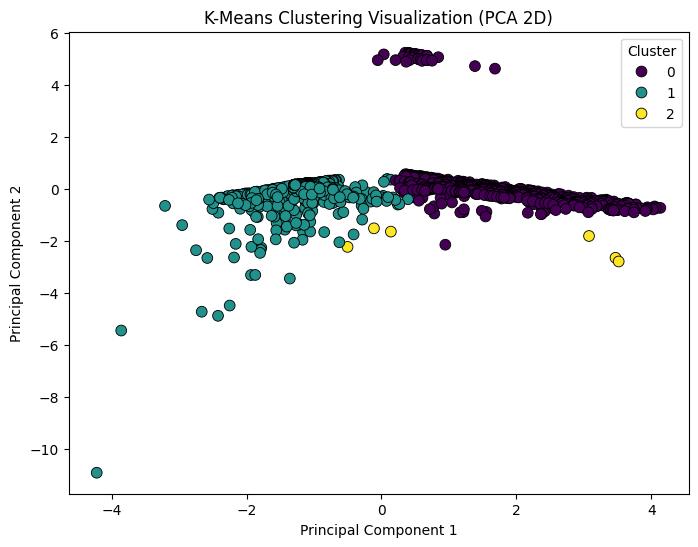


📊 Cluster Centers (in original feature space):
            id          used  original_price  discounted_price  delivery_fee  \
0   410.501577  6.624606e-02   228306.940063     226682.583596           0.0   
1  1207.349771  2.775558e-17    20342.532110      18343.933486           0.0   
2   930.333333  0.000000e+00   148916.500000     147416.166667           0.0   

   average_rating  num_ratings  discount_pct  
0        4.990300     0.182965      0.006341  
1        4.999954    13.488532      0.129195  
2        3.833333    16.833333      0.028350  

📈 Cluster Summary:
                  id      used  original_price  discounted_price  \
Cluster                                                            
0         410.501577  0.066246   228306.940063     226682.583596   
1        1207.349771  0.000000    20342.532110      18343.933486   
2         930.333333  0.000000   148916.500000     147416.166667   

         delivery_fee  average_rating  num_ratings  discount_pct      PCA1  \
Clus

In [1]:
# ======================================
# Assignment 8 – Unsupervised Learning
# K-Means Clustering + PCA Visualization
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns

# 1️⃣ Load dataset
df = pd.read_csv("cleaned_ecommerce.csv")
df.columns = df.columns.str.strip()  # remove extra spaces

# 2️⃣ Select only numeric columns and handle missing values
num_df = df.select_dtypes(include=["int64", "float64"]).fillna(df.mean(numeric_only=True))

# 3️⃣ Standardize data (very important for clustering)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_df)

# 4️⃣ Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels back to dataframe
df["Cluster"] = clusters

# 5️⃣ Reduce dimensions using PCA (for 2D visualization)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
df["PCA1"] = pca_data[:, 0]
df["PCA2"] = pca_data[:, 1]

# 6️⃣ Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="PCA1", y="PCA2", hue="Cluster",
    palette="viridis", data=df, s=60, edgecolor="k"
)
plt.title("K-Means Clustering Visualization (PCA 2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

# 7️⃣ Print cluster insights
print("\n📊 Cluster Centers (in original feature space):")
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=num_df.columns
)
print(centers.head())

# 8️⃣ Optional: check average values per cluster
print("\n📈 Cluster Summary:")
print(df.groupby("Cluster").mean(numeric_only=True))
